# PHASE 1: DATA LOADING
## Basic Data Analysis


In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [2]:
# For Time Series

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [5]:
# For Styling

plt.style.use('ggplot')
sns.set_palette('Set2')

print("="*70)
print("CAR SALES TIME SERIES ANALYSIS")
print("="*70)

CAR SALES TIME SERIES ANALYSIS


In [7]:
# Load Datasets

df = pd.read_csv('car_sales_data.csv')
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [18]:
print(f"\n Dataset loaded: \n \t{df.shape[0]} rows.\n\t{df.shape[1]} columns.")

# f-string (formatted string literal)


 Dataset loaded: 
 	23906 rows.
	16 columns.


In [22]:
# Basic Data Inspection

print("\n First 5 rows:")
print(df.head())

print("\n\n\n Column names and data types:")
print(df.dtypes)

print("\n\n\n Missing values:")
print(df.isnull().sum())

print("\n\n\n Basic statistics for numeric columns:")
print(df.describe())


 First 5 rows:
         Car_id      Date Customer Name Gender  Annual Income  \
0  C_CND_000001  1/2/2022     Geraldine   Male          13500   
1  C_CND_000002  1/2/2022           Gia   Male        1480000   
2  C_CND_000003  1/2/2022        Gianna   Male        1035000   
3  C_CND_000004  1/2/2022       Giselle   Male          13500   
4  C_CND_000005  1/2/2022         Grace   Male        1465000   

                           Dealer_Name   Company       Model  \
0  Buddy Storbeck's Diesel Service Inc      Ford  Expedition   
1                     C & M Motors Inc     Dodge     Durango   
2                          Capitol KIA  Cadillac    Eldorado   
3               Chrysler of Tri-Cities    Toyota      Celica   
4                    Chrysler Plymouth     Acura          TL   

                      Engine Transmission       Color  Price ($)  Dealer_No   \
0  DoubleÂ Overhead Camshaft         Auto       Black      26000  06457-3834   
1  DoubleÂ Overhead Camshaft         Auto       

### Handling Missing Values

Given that there's only one missing value in the `Customer Name` column, we'll drop the corresponding row. This has a negligible impact on the overall dataset size and ensures data completeness for this column.

In [23]:
# Drop rows with any missing values (specifically targeting 'Customer Name' here)
df_cleaned = df.dropna(subset=['Customer Name'])

print(f"Number of rows after dropping missing values: {df_cleaned.shape[0]}")

# Verify that there are no more missing values in 'Customer Name'
print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum())

Number of rows after dropping missing values: 23905

Missing values after cleaning:
Car_id           0
Date             0
Customer Name    0
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64


# PHASE 2: DATA CLEANING AND PREPARATION

In [24]:
# Convert Date to datetime

df['Date'] = pd.to_datetime(df['Date'])

In [25]:
# Clean Price column (remove $ and commas, convert to numeric)

df['Price ($)'] = df['Price ($)'].astype(str).str.replace('$', '', regex=False)
df['Price ($)'] = df['Price ($)'].str.replace(',', '', regex=False)
df['Price ($)'] = pd.to_numeric(df['Price ($)'], errors='coerce')

In [29]:
# Check for any issues

invalid_prices = df['Price ($)'].isna().sum()
if invalid_prices > 0:
    print(f" Found {invalid_prices} rows with invalid prices - removing them")
    df = df.dropna(subset=['Price ($)'])
else:
    print(" No rows with invalid prices found.")

 No rows with invalid prices found.


In [31]:
# Sort by date

df = df.sort_values('Date')

print(f"\n Data cleaned: {len(df)} valid transactions")
print(f" Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f" Price range: ${df['Price ($)'].min():,.0f} to ${df['Price ($)'].max():,.0f}")
print(f" Number of companies: {df['Company'].nunique()}")
print(f" Number of regions: {df['Dealer_Region'].nunique()}")


 Data cleaned: 23906 valid transactions
 Date range: 2022-01-02 00:00:00 to 2023-12-31 00:00:00
 Price range: $1,200 to $85,800
 Number of companies: 30
 Number of regions: 7


## "Aggregate sales volume and revenue daily"

In [32]:
print("\n" + "="*70)
print("DAILY AGGREGATION - SALES VOLUME & REVENUE")
print("="*70)


DAILY AGGREGATION - SALES VOLUME & REVENUE


In [33]:
# Aggregate daily sales volume (count of cars sold)

daily_volume = df.resample('D', on='Date').size().reset_index()
daily_volume.columns = ['Date', 'sales_volume']
daily_volume.set_index('Date', inplace=True)

In [34]:
# Aggregate daily revenue (sum of prices)

daily_revenue = df.resample('D', on='Date')['Price ($)'].sum().reset_index()
daily_revenue.columns = ['Date', 'total_revenue']
daily_revenue.set_index('Date', inplace=True)

In [35]:
# Combine into one dataframe

daily_data = pd.DataFrame({
    'sales_volume': daily_volume['sales_volume'],
    'total_revenue': daily_revenue['total_revenue']
})

In [41]:
# Fill missing dates with 0 (no sales)

date_range = pd.date_range(start=daily_data.index.min(), end=daily_data.index.max(), freq='D')
daily_data = daily_data.reindex(date_range, fill_value=0)

print(f"\n Daily data created: {len(daily_data)} days")
print(f"\n   Date range: {daily_data.index.min()} to {daily_data.index.max()}")
print(f"   Avg daily sales: {daily_data['sales_volume'].mean():.1f} cars")
print(f"   Avg daily revenue: ${daily_data['total_revenue'].mean():,.0f}")
print(f"   Max daily sales: {daily_data['sales_volume'].max()} cars")
print(f"   Max daily revenue: ${daily_data['total_revenue'].max():,.0f}")


 Daily data created: 729 days

   Date range: 2022-01-02 00:00:00 to 2023-12-31 00:00:00
   Avg daily sales: 32.8 cars
   Avg daily revenue: $921,160
   Max daily sales: 190 cars
   Max daily revenue: $5,280,696


In [44]:
 # Save - Daily data

daily_data.to_csv('daily_car_sales.csv')
print("Daily data saved to 'daily_car_sales_data.csv'")

Daily data saved to 'daily_car_sales_data.csv'


# PHASE 3: EXAMINE PATTERNS IN SALES VOLUME AND REVENUE

In [45]:
print("\n" + "="*70)
print("PATTERN ANALYSIS - SALES VOLUME & REVENUE")
print("="*70)



PATTERN ANALYSIS - SALES VOLUME & REVENUE


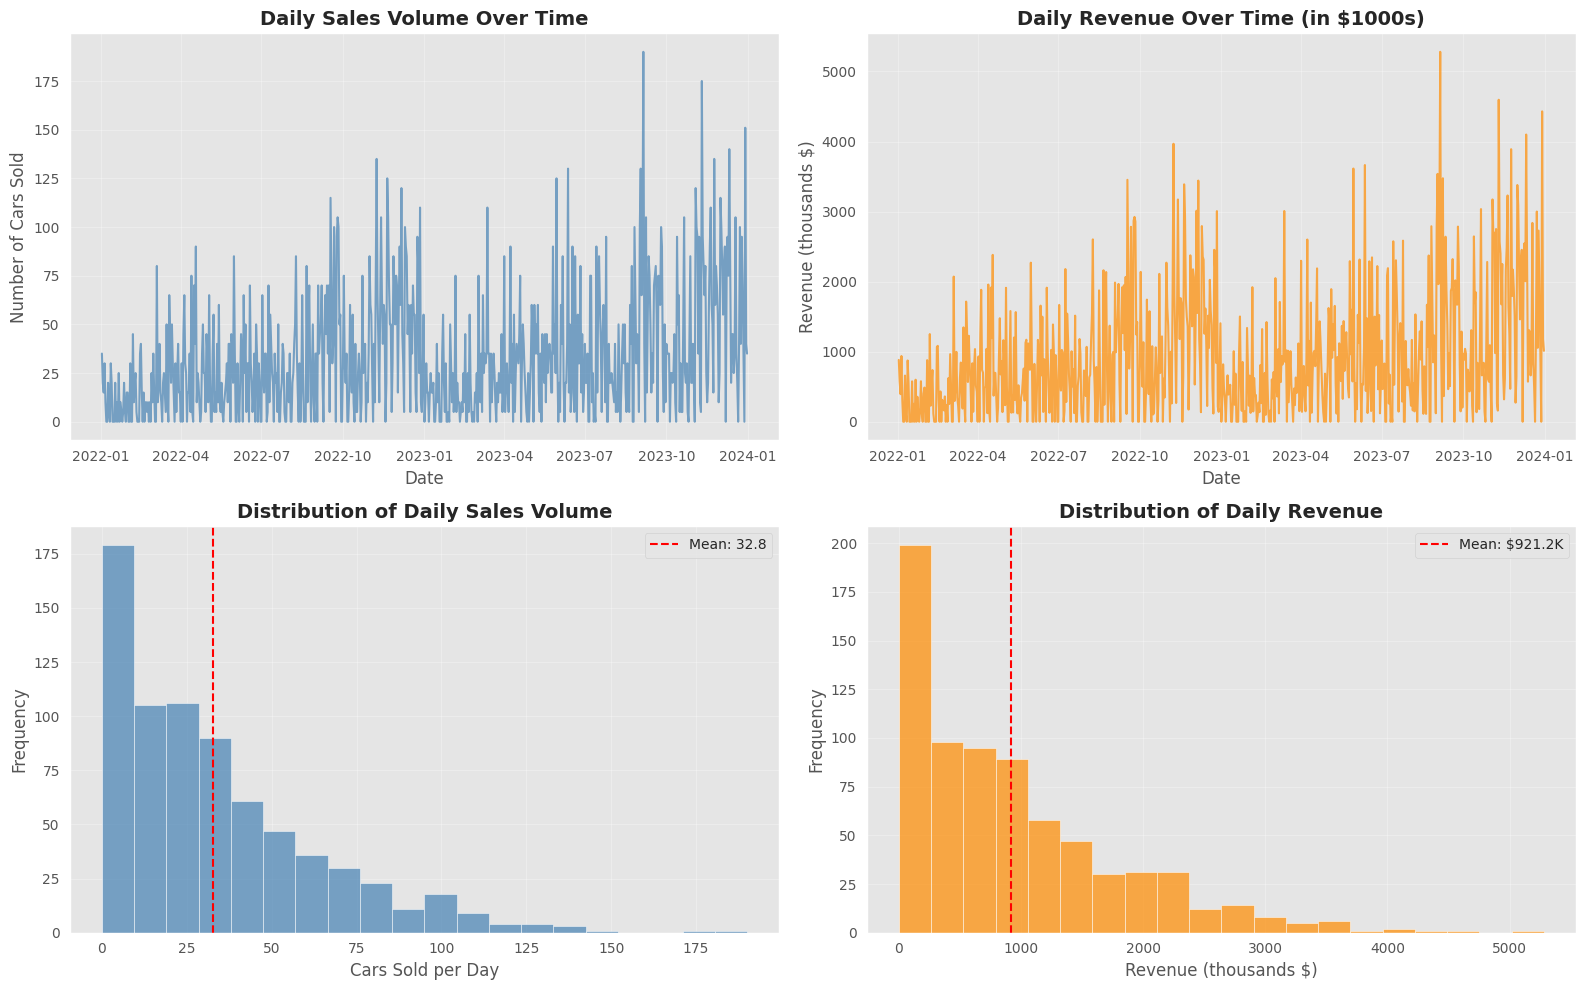

 Pattern visualization saved as 'daily_patterns_overview.png'


In [68]:
# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# Plot 1: Daily sales volume over time

axes[0, 0].plot(daily_data.index, daily_data['sales_volume'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Daily Sales Volume Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Cars Sold')
axes[0, 0].grid(True, alpha=0.3)


# Plot 2: Daily revenue over time

axes[0, 1].plot(daily_data.index, daily_data['total_revenue']/1000, color='darkorange', alpha=0.7)
axes[0, 1].set_title('Daily Revenue Over Time (in $1000s)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Revenue (thousands $)')
axes[0, 1].grid(True, alpha=0.3)


# Plot 3: Distribution of sales volume

axes[1, 0].hist(daily_data['sales_volume'], bins=20, color='steelblue', edgecolor='white', alpha=0.7)
axes[1, 0].axvline(daily_data['sales_volume'].mean(), color='red', linestyle='--',
                   label=f"Mean: {daily_data['sales_volume'].mean():.1f}")
axes[1, 0].set_title('Distribution of Daily Sales Volume', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Cars Sold per Day')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)



# Plot 4: Distribution of daily revenue
axes[1, 1].hist(daily_data['total_revenue']/1000, bins=20, color='darkorange', edgecolor='white', alpha=0.7)
axes[1, 1].axvline(daily_data['total_revenue'].mean()/1000, color='red', linestyle='--',
                   label=f"Mean: ${daily_data['total_revenue'].mean()/1000:.1f}K")
axes[1, 1].set_title('Distribution of Daily Revenue', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Revenue (thousands $)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('daily_patterns_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Pattern visualization saved as 'daily_patterns_overview.png'")

In [69]:
# Business insights from patterns
print("\n  BUSINESS INSIGHTS FROM PATTERNS:")
print("   • The business sells an average of {:.1f} cars per day".format(daily_data['sales_volume'].mean()))
print("   • Average daily revenue: ${:,.0f}".format(daily_data['total_revenue'].mean()))
print("   • There are {} days with zero sales".format((daily_data['sales_volume'] == 0).sum()))
print("   • Top 10% of days account for {:.1f}% of total revenue".format(
    daily_data.nlargest(int(len(daily_data)*0.1), 'total_revenue')['total_revenue'].sum() /
    daily_data['total_revenue'].sum() * 100))


  BUSINESS INSIGHTS FROM PATTERNS:
   • The business sells an average of 32.8 cars per day
   • Average daily revenue: $921,160
   • There are 117 days with zero sales
   • Top 10% of days account for 30.5% of total revenue


# PHASE 4: DAY-OF-WEEK PATTERN ANALYSIS

In [71]:
print("\n" + "="*70)
print("DAY-OF-WEEK PATTERN ANALYSIS")
print("="*70)


DAY-OF-WEEK PATTERN ANALYSIS


In [72]:
# Add day of week column
daily_data['day_of_week'] = daily_data.index.day_name()
daily_data['day_num'] = daily_data.index.dayofweek  # Monday=0, Sunday=6


# Calculate average by day of week
dow_pattern = daily_data.groupby('day_of_week').agg({
    'sales_volume': ['mean', 'std', 'count'],
    'total_revenue': ['mean', 'std']
}).round(1)


# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_pattern = dow_pattern.reindex(day_order)

print("\n Average Sales by Day of Week:")
print(dow_pattern)


 Average Sales by Day of Week:
            sales_volume             total_revenue           
                    mean   std count          mean        std
day_of_week                                                  
Monday              38.5  32.1   104     1082538.6   903655.6
Tuesday             42.5  33.5   104     1185338.5   943925.9
Wednesday           31.2  22.0   104      882916.3   623058.5
Thursday            12.8  16.7   104      365224.6   481781.0
Friday              25.5  36.9   104      721149.4  1039467.4
Saturday            40.1  33.0   104     1116798.7   927518.4
Sunday              38.9  28.3   105     1092504.6   800554.0


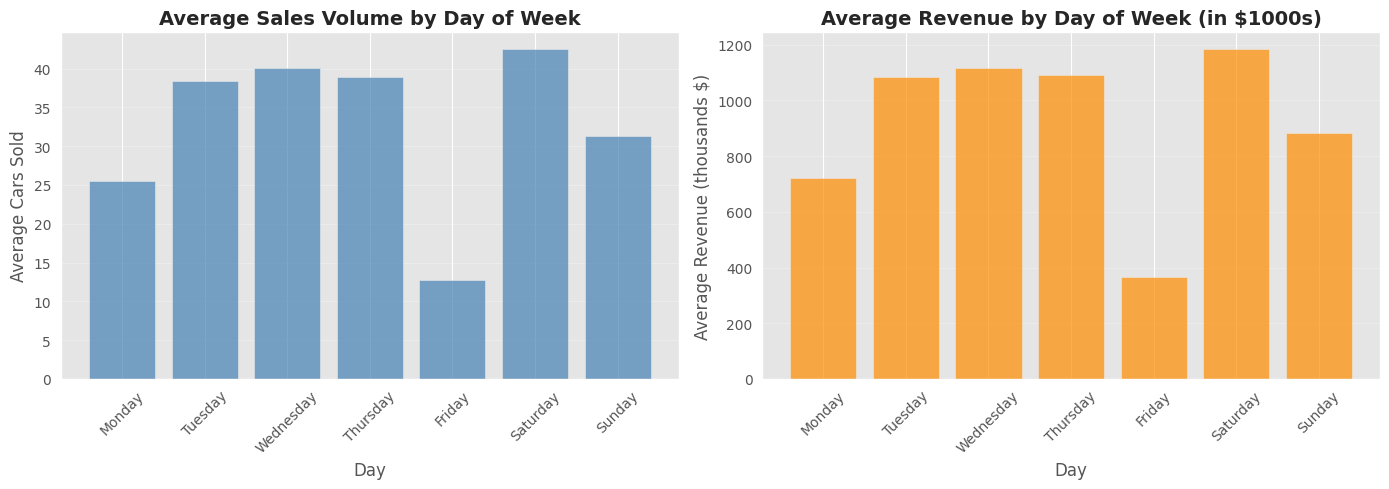

In [73]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Sales volume by day

axes[0].bar(day_order, daily_data.groupby('day_of_week')['sales_volume'].mean(),
            color='steelblue', alpha=0.7)
axes[0].set_title('Average Sales Volume by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Average Cars Sold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')


# Revenue by day

axes[1].bar(day_order, daily_data.groupby('day_of_week')['total_revenue'].mean()/1000,
            color='darkorange', alpha=0.7)
axes[1].set_title('Average Revenue by Day of Week (in $1000s)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average Revenue (thousands $)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('day_of_week_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [74]:
# Business insights

best_day = dow_pattern[('sales_volume', 'mean')].idxmax()
best_day_revenue = dow_pattern[('total_revenue', 'mean')].idxmax()

print("\n  BUSINESS INSIGHTS - WEEKLY PATTERNS:")
print(f"   • Best day for sales volume: {best_day} ({dow_pattern.loc[best_day, ('sales_volume', 'mean')]:.1f} cars avg)")
print(f"   • Best day for revenue: {best_day_revenue} (${dow_pattern.loc[best_day_revenue, ('total_revenue', 'mean')]:,.0f} avg)")
print(f"   • Weekend vs Weekday: Weekend avg: {dow_pattern.loc[['Saturday','Sunday'], ('sales_volume', 'mean')].mean():.1f} cars, " +
      f"Weekday avg: {dow_pattern.loc[['Monday','Tuesday','Wednesday','Thursday','Friday'], ('sales_volume', 'mean')].mean():.1f} cars")


  BUSINESS INSIGHTS - WEEKLY PATTERNS:
   • Best day for sales volume: Tuesday (42.5 cars avg)
   • Best day for revenue: Tuesday ($1,185,338 avg)
   • Weekend vs Weekday: Weekend avg: 39.5 cars, Weekday avg: 30.1 cars


# PHASE 5: MULTIPLE TIME WINDOWS ANALYSIS (7, 30, 90 DAYS)

In [76]:
print("\n" + "="*70)
print("MULTIPLE TIME WINDOWS ANALYSIS")
print("="*70)


MULTIPLE TIME WINDOWS ANALYSIS


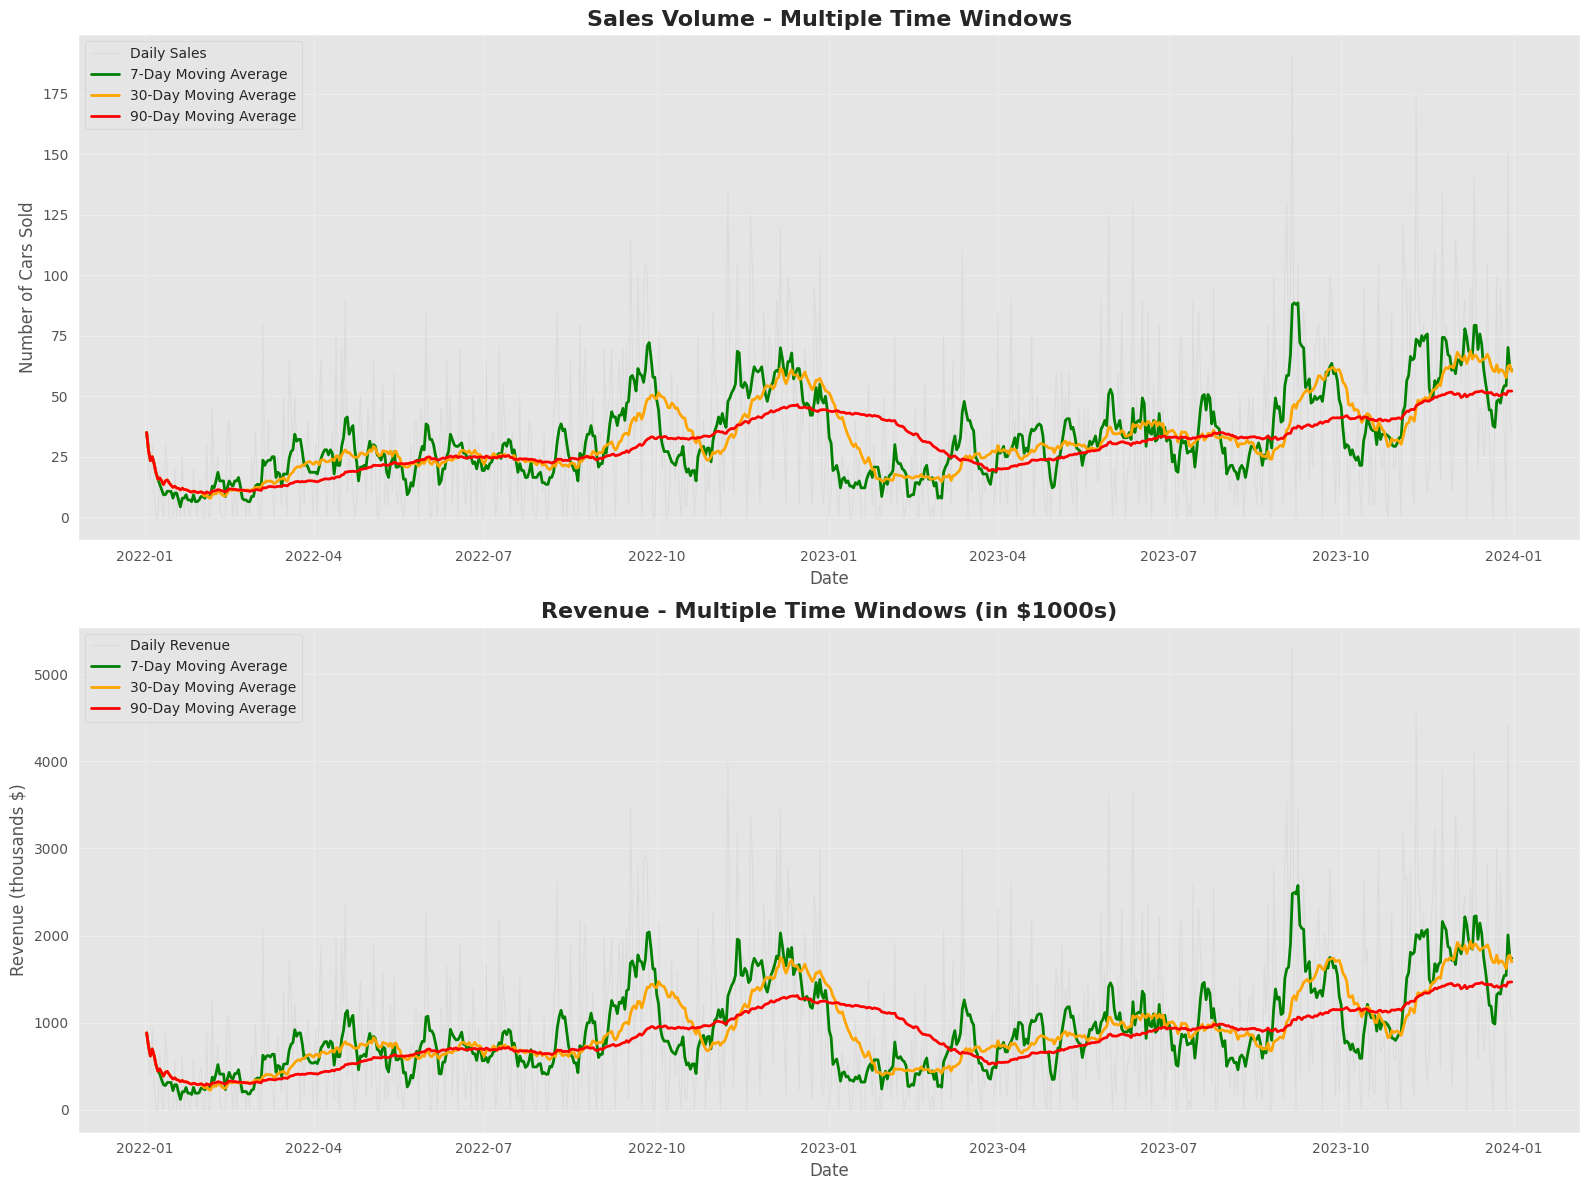

In [95]:
# Calculate rolling averages for different windows

windows = [7, 30, 90]
window_labels = ['7-Day', '30-Day', '90-Day']
colors = ['green', 'orange', 'red']


# Create dataframe with rolling averages
rolling_data = daily_data[['sales_volume', 'total_revenue']].copy()

for window in windows:
    rolling_data[f'sales_ma_{window}'] = daily_data['sales_volume'].rolling(window=window, min_periods=1).mean()
    rolling_data[f'revenue_ma_{window}'] = daily_data['total_revenue'].rolling(window=window, min_periods=1).mean()


# Visualize sales volume with different windows
fig, axes = plt.subplots(2, 1, figsize=(16, 12))


# Sales volume with rolling averages

axes[0].plot(rolling_data.index, rolling_data['sales_volume'],
             color='lightgray', alpha=0.5, label='Daily Sales', linewidth=0.8)

for i, window in enumerate(windows):
    axes[0].plot(rolling_data.index, rolling_data[f'sales_ma_{window}'],
                 color=colors[i], linewidth=2, label=f'{window}-Day Moving Average')

axes[0].set_title('Sales Volume - Multiple Time Windows', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Cars Sold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)


# Revenue with rolling averages
axes[1].plot(rolling_data.index, rolling_data['total_revenue']/1000,
             color='lightgray', alpha=0.5, label='Daily Revenue', linewidth=0.8)

for i, window in enumerate(windows):
    axes[1].plot(rolling_data.index, rolling_data[f'revenue_ma_{window}']/1000,
                 color=colors[i], linewidth=2, label=f'{window}-Day Moving Average')

axes[1].set_title('Revenue - Multiple Time Windows (in $1000s)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Revenue (thousands $)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multiple_windows_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [80]:
print("\n" + "="*70)
print("BUSINESS INSIGHTS FROM DIFFERENT TIME WINDOWS")
print("="*70)


BUSINESS INSIGHTS FROM DIFFERENT TIME WINDOWS


In [83]:
# Current values (last available)

current_sales = rolling_data['sales_volume'].iloc[-1]
current_revenue = rolling_data['total_revenue'].iloc[-1]

print("\n CURRENT STATUS (most recent day):")
print(f"   • Sales: {current_sales} cars")
print(f"   • Revenue: ${current_revenue:,.0f}")


 CURRENT STATUS (most recent day):
   • Sales: 35 cars
   • Revenue: $1,012,406


In [93]:
# Compare with different windows

print("\n TREND ANALYSIS:")
for i, window in enumerate(windows):
    sales_trend = rolling_data[f'sales_ma_{window}'].iloc[-1]
    revenue_trend = rolling_data[f'revenue_ma_{window}'].iloc[-1]

    sales_pct = ((current_sales - sales_trend) / sales_trend) * 100 if sales_trend > 0 else 0
    revenue_pct = ((current_revenue - revenue_trend) / revenue_trend) * 100 if revenue_trend > 0 else 0

    print(f"\n   {window}-Day Window:")
    print(f"      • Average sales: {sales_trend:.1f} cars ({sales_pct:+.1f}% vs current)")
    print(f"      • Average revenue: ${revenue_trend:,.0f} ({revenue_pct:+.1f}% vs current)")

# Business insight based on window
    if window == 7:
        print(f"       Short-term trend (weekly): {'UP' if sales_pct > 0 else 'DOWN'} by {abs(sales_pct):.1f}%")
    elif window == 30:
        print(f"       Monthly trend: {'UP' if sales_pct > 0 else 'DOWN'} by {abs(sales_pct):.1f}%")
    elif window == 90:
        print(f"       Quarterly trend: {'UP' if sales_pct > 0 else 'DOWN'} by {abs(sales_pct):.1f}%")


# Find peaks and troughs
print("\n KEY PATTERNS DETECTED:")

for window in windows:
    sales_ma = rolling_data[f'sales_ma_{window}']

    # Find peak period
    peak_idx = sales_ma.idxmax()
    peak_value = sales_ma.max()
    peak_date = peak_idx.strftime('%Y-%m-%d')

    # Find trough period
    trough_idx = sales_ma.idxmin()
    trough_value = sales_ma.min()
    trough_date = trough_idx.strftime('%Y-%m-%d')

    print(f"\n   {window}-Day Window:")
    print(f"      • Peak period around {peak_date}: {peak_value:.1f} cars avg")
    print(f"      • Low period around {trough_date}: {trough_value:.1f} cars avg")
    print(f"      • Range: {peak_value - trough_value:.1f} cars ({((peak_value - trough_value)/trough_value*100):.0f}% variation)")


 TREND ANALYSIS:

   7-Day Window:
      • Average sales: 60.9 cars (-42.5% vs current)
      • Average revenue: $1,740,412 (-41.8% vs current)
       Short-term trend (weekly): DOWN by 42.5%

   30-Day Window:
      • Average sales: 60.2 cars (-41.9% vs current)
      • Average revenue: $1,696,746 (-40.3% vs current)
       Monthly trend: DOWN by 41.9%

   90-Day Window:
      • Average sales: 52.1 cars (-32.9% vs current)
      • Average revenue: $1,467,327 (-31.0% vs current)
       Quarterly trend: DOWN by 32.9%

 KEY PATTERNS DETECTED:

   7-Day Window:
      • Peak period around 2023-09-06: 88.6 cars avg
      • Low period around 2022-01-20: 4.3 cars avg
      • Range: 84.3 cars (1967% variation)

   30-Day Window:
      • Peak period around 2023-12-09: 68.7 cars avg
      • Low period around 2022-02-05: 7.8 cars avg
      • Range: 60.8 cars (777% variation)

   90-Day Window:
      • Peak period around 2023-12-15: 52.2 cars avg
      • Low period around 2022-02-02: 9.8 cars avg

# PHASE 6: REGIONAL PATTERN ANALYSIS

In [96]:
print("\n" + "="*70)
print("REGIONAL PATTERN ANALYSIS")
print("="*70)


REGIONAL PATTERN ANALYSIS


In [98]:
# Get list of regions
regions = df['Dealer_Region'].unique()
print(f"\n Regions in dataset: {len(regions)}")
for region in sorted(regions)[:10]:  # Show first 10
    count = len(df[df['Dealer_Region'] == region])
    print(f"   • {region}: {count} transactions")

# Create daily aggregates by region
regional_daily = {}

for region in regions:
    # Filter data for region
    region_df = df[df['Dealer_Region'] == region].copy()

    if len(region_df) < 30:  # Skip regions with too little data
        continue

    # Daily aggregation
    region_daily_vol = region_df.resample('D', on='Date').size()
    region_daily_rev = region_df.resample('D', on='Date')['Price ($)'].sum()

    # Create dataframe
    region_data = pd.DataFrame({
        'sales_volume': region_daily_vol,
        'total_revenue': region_daily_rev
    })

    # Reindex to full date range
    region_data = region_data.reindex(date_range, fill_value=0)

    regional_daily[region] = region_data

    print(f"\n Processed {region}: {len(region_data)} days, avg {region_data['sales_volume'].mean():.2f} cars/day")



 Regions in dataset: 7
   • Aurora: 3130 transactions
   • Austin: 4135 transactions
   • Greenville: 3128 transactions
   • Janesville: 3821 transactions
   • Middletown: 3128 transactions
   • Pasco: 3131 transactions
   • Scottsdale: 3433 transactions

 Processed Middletown: 729 days, avg 4.29 cars/day

 Processed Austin: 729 days, avg 5.67 cars/day

 Processed Pasco: 729 days, avg 4.29 cars/day

 Processed Scottsdale: 729 days, avg 4.71 cars/day

 Processed Janesville: 729 days, avg 5.24 cars/day

 Processed Aurora: 729 days, avg 4.29 cars/day

 Processed Greenville: 729 days, avg 4.29 cars/day


In [99]:
print("\n" + "="*70)
print("REGION-SPECIFIC PATTERNS")
print("="*70)


REGION-SPECIFIC PATTERNS


In [101]:
# Calculate regional statistics
region_stats = []
for region, data in regional_daily.items():
    if len(data) > 0:
        region_stats.append({
            'region': region,
            'total_sales': data['sales_volume'].sum(),
            'total_revenue': data['total_revenue'].sum(),
            'avg_daily_sales': data['sales_volume'].mean(),
            'avg_daily_revenue': data['total_revenue'].mean(),
            'peak_day_sales': data['sales_volume'].max(),
            'peak_day_revenue': data['total_revenue'].max(),
            'zero_days': (data['sales_volume'] == 0).sum(),
            'data_days': len(data)
        })

region_df = pd.DataFrame(region_stats)
region_df = region_df.sort_values('total_sales', ascending=False)

print("\n Top 10 Regions by Total Sales:")
print(region_df[['region', 'total_sales', 'avg_daily_sales', 'total_revenue']].head(10).to_string(index=False))

# Select top 5 regions for detailed comparison
top_regions = region_df.head(5)['region'].tolist()
print(f"\n Selected top 5 regions for detailed pattern analysis: {top_regions}")



 Top 10 Regions by Total Sales:
    region  total_sales  avg_daily_sales  total_revenue
    Austin         4135         5.672154      117192531
Janesville         3821         5.241427      106351234
Scottsdale         3433         4.709191       95969374
     Pasco         3131         4.294925       88040714
    Aurora         3130         4.293553       88687382
Middletown         3128         4.290809       87134628
Greenville         3128         4.290809       88149602

 Selected top 5 regions for detailed pattern analysis: ['Austin', 'Janesville', 'Scottsdale', 'Pasco', 'Aurora']


In [102]:
print("\n" + "="*70)
print("REGIONAL PATTERN COMPARISON")
print("="*70)


REGIONAL PATTERN COMPARISON


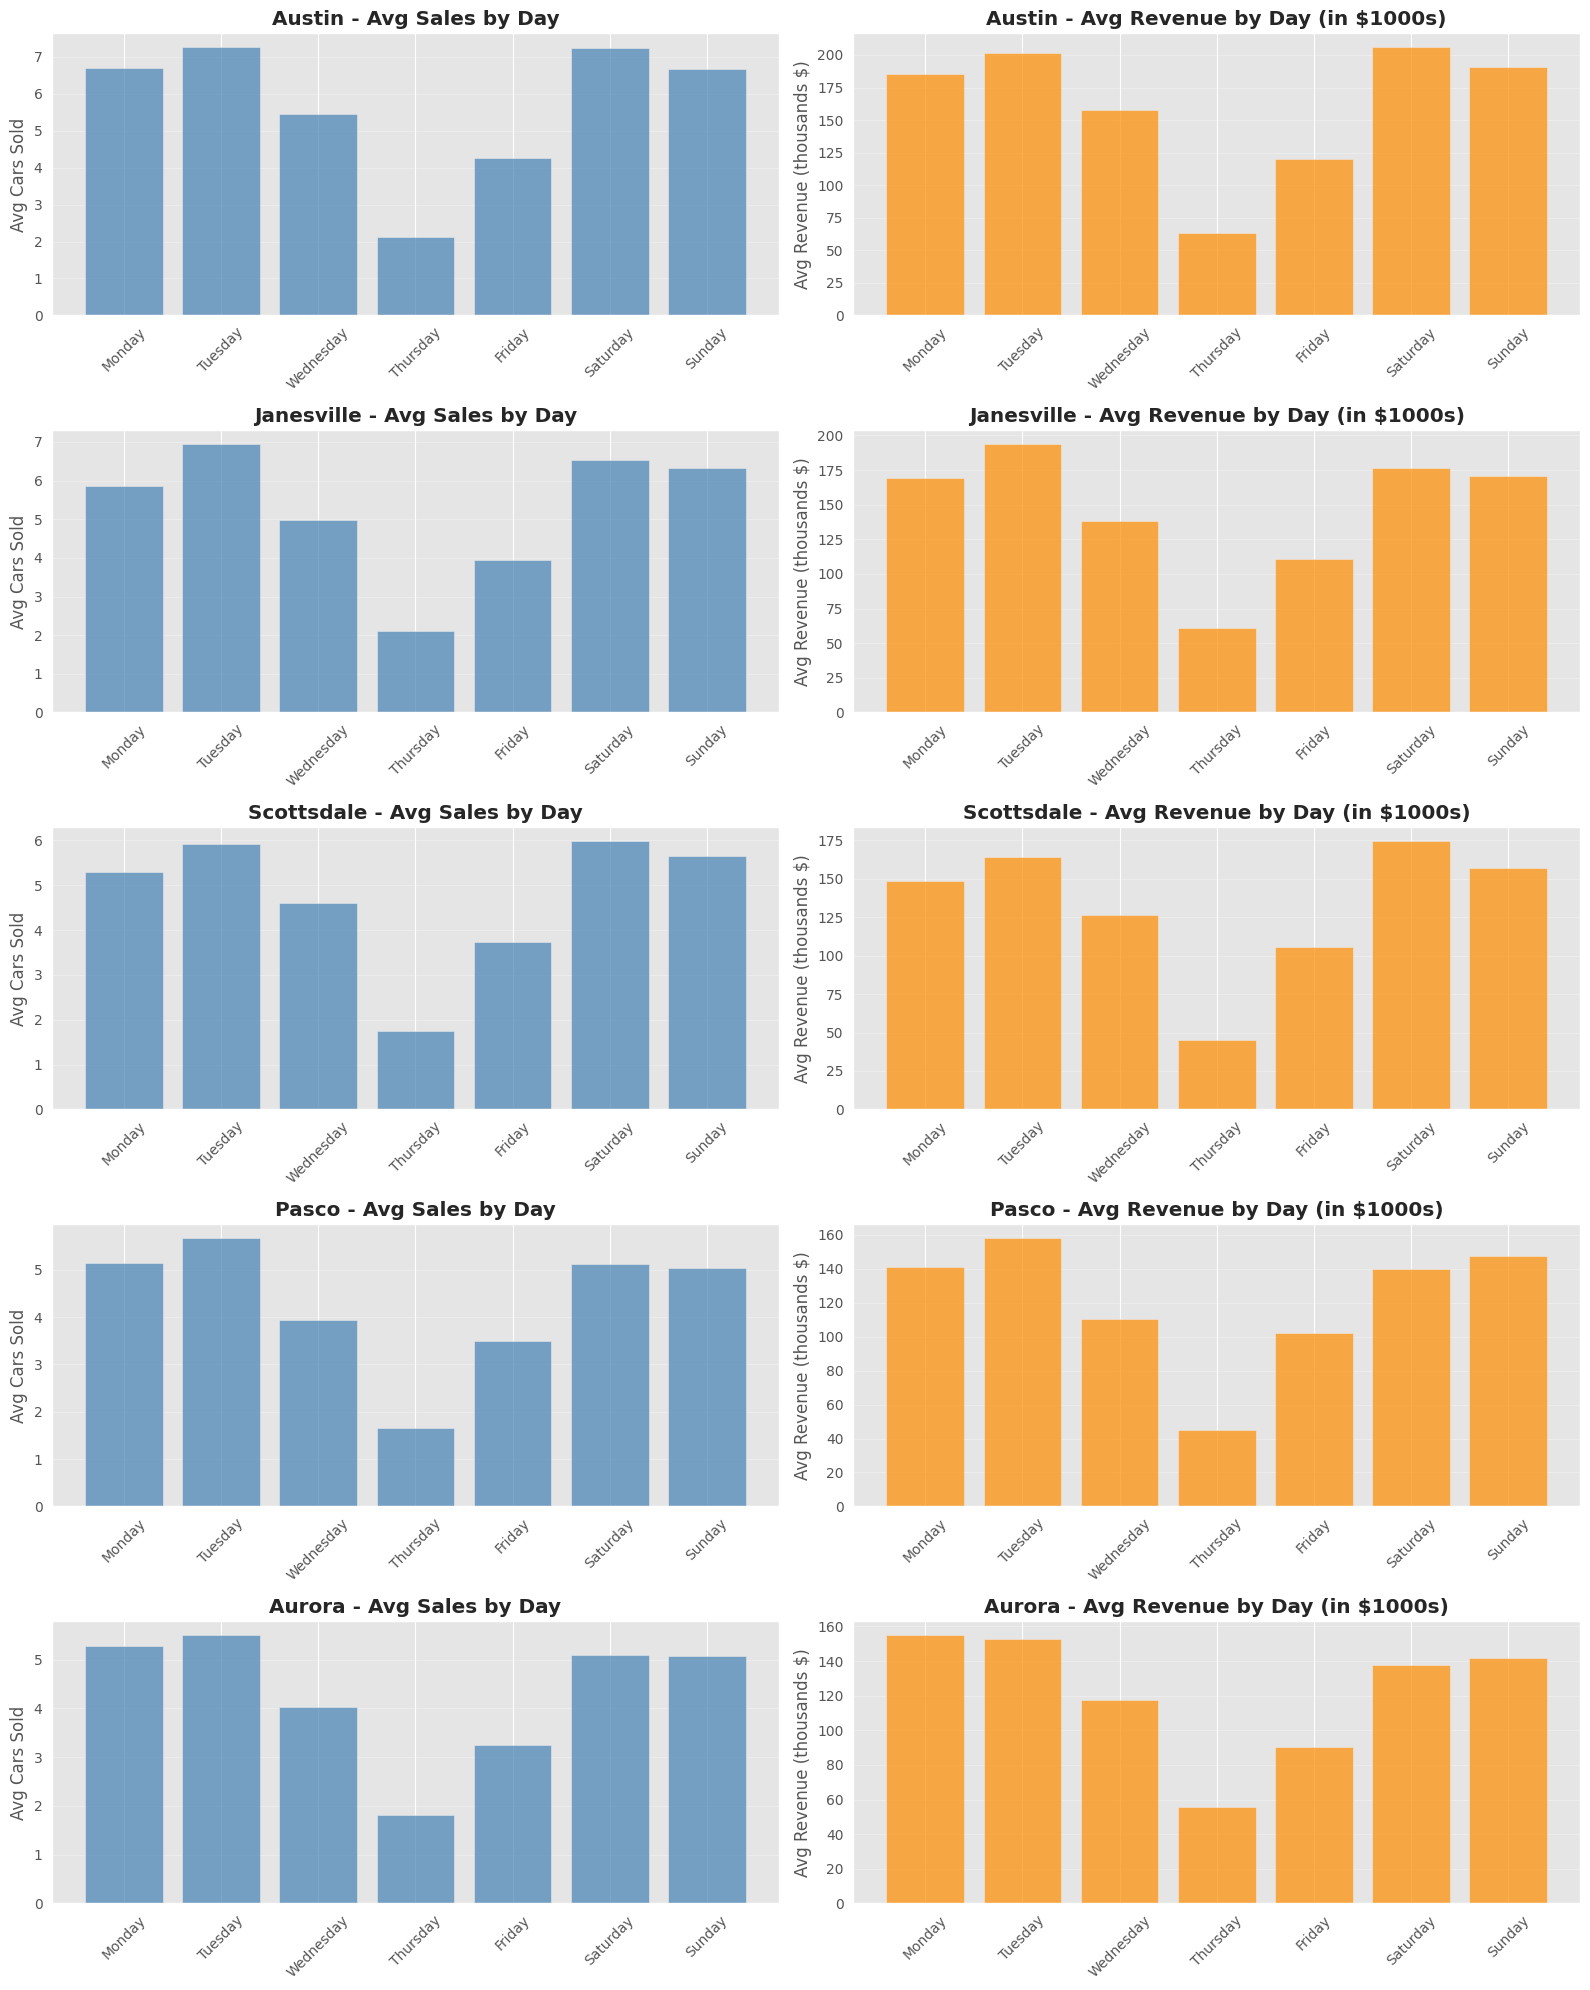

In [103]:
# Compare day-of-week patterns across top regions
fig, axes = plt.subplots(len(top_regions), 2, figsize=(16, 4*len(top_regions)))

for i, region in enumerate(top_regions):
    region_data = regional_daily[region].copy()
    region_data['day_of_week'] = region_data.index.day_name()

    # Sales volume by day
    dow_sales = region_data.groupby('day_of_week')['sales_volume'].mean().reindex(day_order)

    axes[i, 0].bar(day_order, dow_sales.values, color='steelblue', alpha=0.7)
    axes[i, 0].set_title(f'{region} - Avg Sales by Day', fontweight='bold')
    axes[i, 0].set_ylabel('Avg Cars Sold')
    axes[i, 0].tick_params(axis='x', rotation=45)
    axes[i, 0].grid(True, alpha=0.3, axis='y')

    # Revenue by day
    dow_revenue = region_data.groupby('day_of_week')['total_revenue'].mean().reindex(day_order)

    axes[i, 1].bar(day_order, dow_revenue.values/1000, color='darkorange', alpha=0.7)
    axes[i, 1].set_title(f'{region} - Avg Revenue by Day (in $1000s)', fontweight='bold')
    axes[i, 1].set_ylabel('Avg Revenue (thousands $)')
    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('regional_pattern_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [104]:
print("\n" + "="*70)
print("BUSINESS IMPLICATIONS - REGIONAL PATTERNS")
print("="*70)


BUSINESS IMPLICATIONS - REGIONAL PATTERNS



 Regional Weekend vs Weekday Patterns:
    region  weekend_avg  weekday_avg  weekend_ratio            effect
    Austin     6.952153     5.157692       1.347919 Stronger weekends
Janesville     6.421053     4.767308       1.346893 Stronger weekends
Scottsdale     5.822967     4.261538       1.366400 Stronger weekends
     Pasco     5.071770     3.982692       1.273453 Stronger weekends
    Aurora     5.081340     3.976923       1.277706 Stronger weekends

 BUSINESS IMPLICATIONS BY REGION:

    Austin:
      • Total sales: 4135 cars
      • Average transaction: $28,342
      • Peak month: November
      • Marketing implication: Weekend traffic is 1.3x higher - focus weekend promotions

    Janesville:
      • Total sales: 3821 cars
      • Average transaction: $27,833
      • Peak month: December
      • Marketing implication: Weekend traffic is 1.3x higher - focus weekend promotions

    Scottsdale:
      • Total sales: 3433 cars
      • Average transaction: $27,955
      • Peak month

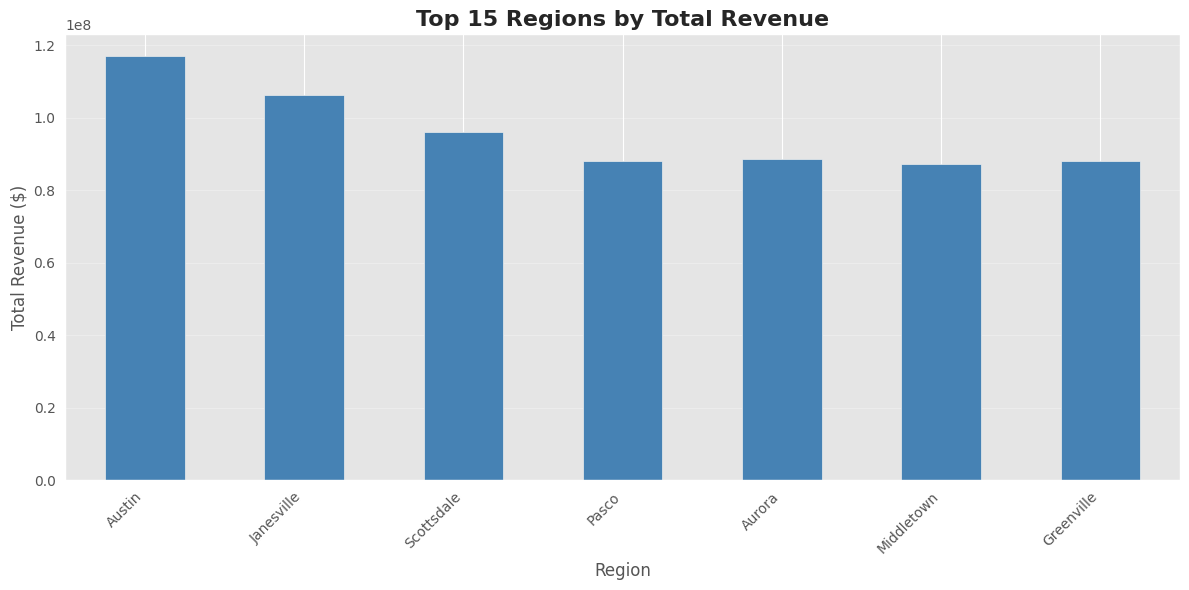

In [108]:
# Find which region has strongest weekend effect
weekend_effects = []
for region in top_regions:
    region_data = regional_daily[region]
    region_data['day_num'] = region_data.index.dayofweek
    weekend_avg = region_data[region_data['day_num'].isin([5, 6])]['sales_volume'].mean()  # Sat & Sun
    weekday_avg = region_data[region_data['day_num'].isin([0,1,2,3,4])]['sales_volume'].mean()

    if weekday_avg > 0:
        weekend_ratio = weekend_avg / weekday_avg
        weekend_effects.append({
            'region': region,
            'weekend_avg': weekend_avg,
            'weekday_avg': weekday_avg,
            'weekend_ratio': weekend_ratio,
            'effect': 'Stronger weekends' if weekend_ratio > 1.2 else 'Normal' if weekend_ratio > 0.8 else 'Stronger weekdays'
        })

weekend_df = pd.DataFrame(weekend_effects)
print("\n Regional Weekend vs Weekday Patterns:")
print(weekend_df.to_string(index=False))

print("\n BUSINESS IMPLICATIONS BY REGION:")

for region in top_regions:
    region_data = regional_daily[region]

    # Key metrics
    total_sales = region_data['sales_volume'].sum()
    avg_price = region_data['total_revenue'].sum() / total_sales if total_sales > 0 else 0
    peak_month = region_data.groupby(region_data.index.month)['sales_volume'].sum().idxmax()

    print(f"\n    {region}:")
    print(f"      • Total sales: {total_sales:.0f} cars")
    print(f"      • Average transaction: ${avg_price:,.0f}")
    print(f"      • Peak month: {pd.to_datetime(f'2022-{peak_month:02d}-01').strftime('%B')}")

    # Specific business implications
    if weekend_ratio > 1.2:
        print(f"      • Marketing implication: Weekend traffic is {weekend_ratio:.1f}x higher - focus weekend promotions")
    elif weekend_ratio < 0.8:
        print(f"      • Marketing implication: Weekday traffic is stronger - target business customers")

    if avg_price > 50000:
        print(f"      •  Premium market - focus on luxury inventory")
    elif avg_price < 25000:
        print(f"      •  Value market - emphasize affordability")

# Regional revenue contribution
region_revenue = region_df.set_index('region')['total_revenue']
plt.figure(figsize=(12, 6))
region_revenue.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Regions by Total Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('regional_revenue_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# PHASE 7: TIME SERIES STATIONARITY TESTING
## Preparation for forecasting

In [109]:
print("\n" + "="*70)
print("TIME SERIES STATIONARITY TESTING")
print("="*70)


TIME SERIES STATIONARITY TESTING



****************************************
TESTING SALES VOLUME SERIES
****************************************

 Daily Sales Volume
   Test Statistic: -2.5601
   p-value: 0.1015
   Critical Values:
      1%: -3.4396
      5%: -2.8656
      10%: -2.5689
    NON-STATIONARY

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
TESTING REVENUE SERIES
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

 Daily Revenue
   Test Statistic: -2.5467
   p-value: 0.1045
   Critical Values:
      1%: -3.4396
      5%: -2.8656
      10%: -2.5689
    NON-STATIONARY

 Applying transformations to achieve stationarity...

 Log-Differenced Revenue
   Test Statistic: -10.2926
   p-value: 0.0000
   Critical Values:
      1%: -3.4396
      5%: -2.8656
      10%: -2.5689
    STATIONARY


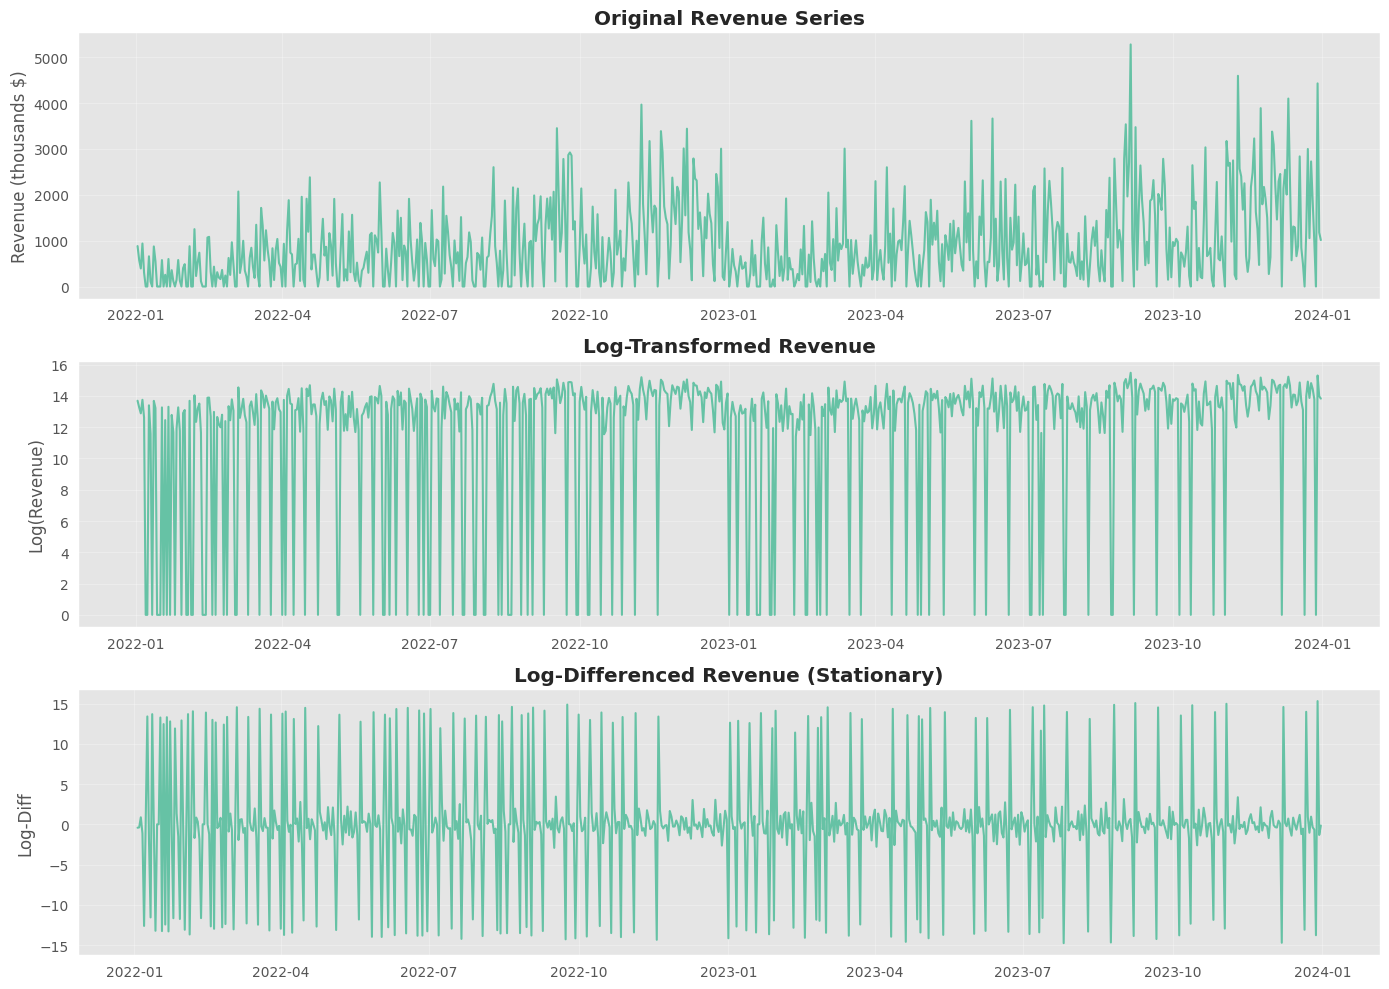

In [112]:
def check_stationarity(series, title):
    """Perform ADF test and return result"""
    result = adfuller(series.dropna())

    print(f"\n {title}")
    print(f"   Test Statistic: {result[0]:.4f}")
    print(f"   p-value: {result[1]:.4f}")
    print('   Critical Values:')
    for key, value in result[4].items():
        print(f'      {key}: {value:.4f}')

    if result[1] <= 0.05:
        print("    STATIONARY")
        return True
    else:
        print("    NON-STATIONARY")
        return False

# Test sales volume
print("\n" + "*"*40)
print("TESTING SALES VOLUME SERIES")
print("*"*40)

is_stationary = check_stationarity(daily_data['sales_volume'], 'Daily Sales Volume')

# Test revenue
print("\n" + "~"*40)
print("TESTING REVENUE SERIES")
print("~"*40)

is_stationary = check_stationarity(daily_data['total_revenue'], 'Daily Revenue')

# If non-stationary, show transformations
if not is_stationary:
    print("\n Applying transformations to achieve stationarity...")

    # Log transformation
    log_revenue = np.log(daily_data['total_revenue'].replace(0, 1))  # Replace 0 with 1 for log

    # First difference
    diff_revenue = daily_data['total_revenue'].diff().dropna()

    # Log-difference
    log_diff_revenue = log_revenue.diff().dropna()

    # Test transformed series
    check_stationarity(log_diff_revenue, 'Log-Differenced Revenue')

    # Visualize
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    axes[0].plot(daily_data.index, daily_data['total_revenue']/1000)
    axes[0].set_title('Original Revenue Series', fontweight='bold')
    axes[0].set_ylabel('Revenue (thousands $)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(log_revenue.index, log_revenue)
    axes[1].set_title('Log-Transformed Revenue', fontweight='bold')
    axes[1].set_ylabel('Log(Revenue)')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(log_diff_revenue.index, log_diff_revenue)
    axes[2].set_title('Log-Differenced Revenue (Stationary)', fontweight='bold')
    axes[2].set_ylabel('Log-Diff')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('stationarity_transformations.png', dpi=150)
    plt.show()


# PHASE 8: FINAL SUMMARY AND INSIGHTS

In [114]:
print("\n" + "="*80)
print("FINAL SUMMARY - CAR SALES BUSINESS INSIGHTS")
print("="*80)


FINAL SUMMARY - CAR SALES BUSINESS INSIGHTS


In [117]:
print("\nEXECUTIVE SUMMARY")
print("_"*40)

print("""
Based on the comprehensive time series analysis of car sales data,
we have identified key patterns and business implications across
multiple dimensions: daily operations, multiple time windows,
and regional variations.
""")


EXECUTIVE SUMMARY
________________________________________

Based on the comprehensive time series analysis of car sales data, 
we have identified key patterns and business implications across 
multiple dimensions: daily operations, multiple time windows, 
and regional variations.



In [120]:
# Section 1: Overall Business Model
print("\n1️ OVERALL BUSINESS MODEL")
print("-"*40)
print(f"   • Average daily sales: {daily_data['sales_volume'].mean():.1f} cars")
print(f"   • Average daily revenue: ${daily_data['total_revenue'].mean():,.0f}")
print(f"   • Average transaction value: ${daily_data['total_revenue'].sum()/daily_data['sales_volume'].sum():,.0f}")
print(f"   • Total analyzed period: {len(daily_data)} days")


1️ OVERALL BUSINESS MODEL
----------------------------------------
   • Average daily sales: 32.8 cars
   • Average daily revenue: $921,160
   • Average transaction value: $28,090
   • Total analyzed period: 729 days


In [121]:
# Section 2: Time Window Insights
print("\n2️ MULTI-WINDOW TREND ANALYSIS")
print("-"*40)

latest_sales = daily_data['sales_volume'].iloc[-1]
latest_revenue = daily_data['total_revenue'].iloc[-1]

for window in windows:
    sales_trend = rolling_data[f'sales_ma_{window}'].iloc[-1]
    revenue_trend = rolling_data[f'revenue_ma_{window}'].iloc[-1]

    sales_dir = "increasing" if latest_sales > sales_trend else "decreasing"
    revenue_dir = "increasing" if latest_revenue > revenue_trend else "decreasing"

    print(f"\n   {window}-Day Window:")
    print(f"      • Sales trend: {sales_dir} (avg {sales_trend:.1f} cars)")
    print(f"      • Revenue trend: {revenue_dir} (avg ${revenue_trend:,.0f})")


2️ MULTI-WINDOW TREND ANALYSIS
----------------------------------------

   7-Day Window:
      • Sales trend: decreasing (avg 60.9 cars)
      • Revenue trend: decreasing (avg $1,740,412)

   30-Day Window:
      • Sales trend: decreasing (avg 60.2 cars)
      • Revenue trend: decreasing (avg $1,696,746)

   90-Day Window:
      • Sales trend: decreasing (avg 52.1 cars)
      • Revenue trend: decreasing (avg $1,467,327)


In [122]:
# Section 3: Regional Highlights
print("\n3️ REGIONAL HIGHLIGHTS")
print("-"*40)

top_region = region_df.iloc[0]
print(f"\n    Top Performing Region: {top_region['region']}")
print(f"      • Total sales: {top_region['total_sales']:.0f} cars")
print(f"      • Total revenue: ${top_region['total_revenue']:,.0f}")
print(f"      • Average daily: {top_region['avg_daily_sales']:.1f} cars")

second_region = region_df.iloc[1] if len(region_df) > 1 else None
if second_region is not None:
    print(f"\n    Second Place: {second_region['region']}")
    print(f"      • Total sales: {second_region['total_sales']:.0f} cars")
    print(f"      • Gap to leader: {((top_region['total_sales'] - second_region['total_sales'])/second_region['total_sales']*100):.0f}%")


3️ REGIONAL HIGHLIGHTS
----------------------------------------

    Top Performing Region: Austin
      • Total sales: 4135 cars
      • Total revenue: $117,192,531
      • Average daily: 5.7 cars

    Second Place: Janesville
      • Total sales: 3821 cars
      • Gap to leader: 8%


In [123]:
# Section 4: Actionable Recommendations
print("\n4️ ACTIONABLE RECOMMENDATIONS")
print("-"*40)

print("""
   A. OPERATIONS:
      • Staff accordingly on peak days (identified in day-of-week analysis)
      • Adjust inventory based on 30-day rolling average trends
      • Monitor regions with high zero-day counts for data quality issues

   B. MARKETING:
      • Target weekend promotions in regions with strong weekend traffic
      • Adjust messaging based on regional price points (luxury vs value)
      • Allocate budget to top-performing regions for highest ROI

   C. STRATEGIC:
      • Investigate causes of 90-day trend directions
      • Use 7-day windows for short-term operational planning
      • Use 30-day windows for monthly target setting
      • Use 90-day windows for quarterly business reviews
""")


4️ ACTIONABLE RECOMMENDATIONS
----------------------------------------

   A. OPERATIONS:
      • Staff accordingly on peak days (identified in day-of-week analysis)
      • Adjust inventory based on 30-day rolling average trends
      • Monitor regions with high zero-day counts for data quality issues
   
   B. MARKETING:
      • Target weekend promotions in regions with strong weekend traffic
      • Adjust messaging based on regional price points (luxury vs value)
      • Allocate budget to top-performing regions for highest ROI
   
   C. STRATEGIC:
      • Investigate causes of 90-day trend directions
      • Use 7-day windows for short-term operational planning
      • Use 30-day windows for monthly target setting
      • Use 90-day windows for quarterly business reviews



In [124]:
# Save all results to CSV for client
summary_df = pd.DataFrame({
    'metric': ['total_days', 'total_sales', 'total_revenue', 'avg_daily_sales',
               'avg_daily_revenue', 'avg_transaction_value', 'peak_sales_day', 'peak_revenue_day'],
    'value': [
        len(daily_data),
        daily_data['sales_volume'].sum(),
        f"${daily_data['total_revenue'].sum():,.0f}",
        f"{daily_data['sales_volume'].mean():.1f} cars",
        f"${daily_data['total_revenue'].mean():,.0f}",
        f"${daily_data['total_revenue'].sum()/daily_data['sales_volume'].sum():,.0f}",
        f"{daily_data['sales_volume'].max()} cars on {daily_data['sales_volume'].idxmax().strftime('%Y-%m-%d')}",
        f"${daily_data['total_revenue'].max():,.0f} on {daily_data['total_revenue'].idxmax().strftime('%Y-%m-%d')}"
    ]
})

summary_df.to_csv('sales_analysis_summary.csv', index=False)
region_df.to_csv('regional_analysis_summary.csv', index=False)
rolling_data.to_csv('rolling_window_analysis.csv')

print("\n All analysis complete! Results saved to CSV files:")
print("   • sales_analysis_summary.csv")
print("   • regional_analysis_summary.csv")
print("   • rolling_window_analysis.csv")
print("   • daily_car_sales.csv")
print("\n Visualizations saved:")
print("   • daily_patterns_overview.png")
print("   • day_of_week_patterns.png")
print("   • multiple_windows_analysis.png")
print("   • regional_pattern_comparison.png")
print("   • regional_revenue_ranking.png")
print("   • stationarity_transformations.png")


 All analysis complete! Results saved to CSV files:
   • sales_analysis_summary.csv
   • regional_analysis_summary.csv
   • rolling_window_analysis.csv
   • daily_car_sales.csv

 Visualizations saved:
   • daily_patterns_overview.png
   • day_of_week_patterns.png
   • multiple_windows_analysis.png
   • regional_pattern_comparison.png
   • regional_revenue_ranking.png
   • stationarity_transformations.png
